# Demo

This demo walks through:
1. Making a layer/gate set for an IBM device.
2. Creating a 2-local Pauli-Lindblad model based on the device topology.
3. Build "vanilla" Pauli-Lindblad learning experiments.
4. Running the experiments.
5. Fitting the model and getting noise maps.

In [1]:
import numpy as np
import qiskit.quantum_info as qi
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeFez

from qiskit_noise_learning.aer_executor import AerExecutor

backend = FakeFez()

## 1. Build a gate set with a single layer on a ring of qubits

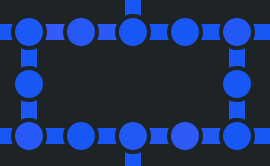

In [2]:
from qiskit_noise_learning.gate_sets import QiskitGateSet

qubit_subset = [*range(25, 30), *range(37, 39), *range(45, 50)]
gate_set = QiskitGateSet(backend.num_qubits, target=backend.target, qubit_subset=qubit_subset)

layer_1_pairs = [(25, 26), (27, 28), (29, 38), (37, 45), (46, 47), (48, 49)]

with gate_set.build_new_gate("layer_1") as builder:
    for pair in layer_1_pairs:
        builder.circuit.cz(*pair)

gate_set.draw()

## 2. Create a 2-local Pauli-Lindblad model.

In [48]:
from qiskit_noise_learning.models import PauliLindbladModel

pauli_lindblad_model = PauliLindbladModel.k_local(gate_set, k=2)
pauli_lindblad_1local = PauliLindbladModel.k_local(gate_set, k=1)


# set to 1 local
pauli_lindblad_model.generators["M"] = pauli_lindblad_1local.generators["M"]
pauli_lindblad_model.generators["P"] = pauli_lindblad_1local.generators["P"]
"""

# Neglecting SPAM for now:
pauli_lindblad_model.generators["M"] = qi.QubitSparsePauliList.empty(
    pauli_lindblad_model.gate_set.num_qubits
)
pauli_lindblad_model.generators["P"] = qi.QubitSparsePauliList.empty(
    pauli_lindblad_model.gate_set.num_qubits
)
"""

pauli_lindblad_model.generators

{'M': <QubitSparsePauliList with 12 elements on 156 qubits: [X_25, X_26, X_27, X_28, X_29, X_37, X_38, X_45, X_46, X_47, X_48, X_49]>,
 'P': <QubitSparsePauliList with 12 elements on 156 qubits: [X_25, X_26, X_27, X_28, X_29, X_37, X_38, X_45, X_46, X_47, X_48, X_49]>,
 'layer_1': <QubitSparsePauliList with 144 elements on 156 qubits: [Z_25, X_25, Y_25, Z_26, X_26, Y_26, Z_27, X_27, Y_27, Z_28, X_28, Y_28, Z_29, X_29, Y_29, Z_38, X_38, Y_38, Z_37, X_37, Y_37, Z_45, X_45, Y_45, Z_46, X_46, Y_46, Z_47, X_47, Y_47, Z_48, X_48, Y_48, Z_49, X_49, Y_49, Z_26 Z_25, Z_26 X_25, Z_26 Y_25, X_26 Z_25, X_26 X_25, X_26 Y_25, Y_26 Z_25, Y_26 X_25, Y_26 Y_25, Z_37 Z_25, Z_37 X_25, Z_37 Y_25, X_37 Z_25, X_37 X_25, X_37 Y_25, Y_37 Z_25, Y_37 X_25, Y_37 Y_25, Z_27 Z_26, Z_27 X_26, Z_27 Y_26, X_27 Z_26, X_27 X_26, X_27 Y_26, Y_27 Z_26, Y_27 X_26, Y_27 Y_26, Z_28 Z_27, Z_28 X_27, Z_28 Y_27, X_28 Z_27, X_28 X_27, X_28 Y_27, Y_28 Z_27, Y_28 X_27, Y_28 Y_27, Z_29 Z_28, Z_29 X_28, Z_29 Y_28, X_29 Z_28, X_29 X

## 3. Build learning experiments

In [49]:
from qiskit_noise_learning.experiment_builder import (
    BindSequenceDepths,
    CompleteSequences,
    Depth1Paths,
    EvenDepthPaths,
    Experiment,
    EvenDepthVanillaPaths,
    GenerateInstructionSequences,
    IdentifyRelations,
    MergeInstructionSequences,
    RankReducePaths,
    SPAMPaths
)

# experiment = Experiment(fidelity_model=pauli_lindblad_model, shots=20, randomizations=50)
experiment = Experiment(fidelity_model=pauli_lindblad_model, shots=2**14, randomizations=1)  # 50)

experiment_builder = (
    # add paths
    #EvenDepthVanillaPaths()
    EvenDepthPaths()
    + Depth1Paths()
    + SPAMPaths(indices_list=[x.indices for x in pauli_lindblad_model.generators["P"]]) # note these add nothing 
    + RankReducePaths()
    #EvenDepthVanillaPaths()
    # add instruction sequences measuring 9 bases
    # + VanillaInstructionSequences()
    #+ GenerateInstructionSequences()
    #+ MergeInstructionSequences()
    # relate them to the paths, and complete them
    #+ IdentifyRelations()
    #+ CompleteSequences()
    # set numerical parameters
    # + BindSequenceDepths([0, 2, 16, 32, 64, 128])
    #+ BindSequenceDepths([1, 2, 16, 32, 64, 128])
)

experiment = experiment_builder.run(experiment)
print(experiment)
print(f"total number of parameters: {sum(len(x) for x in pauli_lindblad_model.generators.values())}")

Experiment:
  Fidelity model: <qiskit_noise_learning.models.pauli_lindblad_model.PauliLindbladModel object at 0x11ad79cd0>
  Paths: 156 (132 unbound, 24 bound)
  Instruction sequences: None
  Relations: None
  Shots: 16384
  Randomizations: 1
  Randomization multipliers: None
total number of parameters: 168


# 4. Build random model data and `AveragedData` directly without simulation

In [50]:
from qiskit_noise_learning.models.pauli_lindblad_model import GeneratorIndex
from qiskit_noise_learning.data import ModelData, AveragedData

# should have a method for generating random model data?

noise_mag = 1e-4

generator_indices = []
for gate in pauli_lindblad_model.gate_set:
    for generator in pauli_lindblad_model.generators[gate]:
        generator_indices.append(GeneratorIndex(gate, generator))

rand_rates = 1e-4 * np.random.random(len(generator_indices))

rand_model_data = ModelData.from_arrays(
    parameter_indices=generator_indices,
    parameter_values=rand_rates,
    covariance=np.zeros((len(generator_indices),)*2, dtype=float),
    time_lbs=np.empty(len(generator_indices), dtype="datetime64[us]"),
    time_ubs=np.empty(len(generator_indices), dtype="datetime64[us]"),
)

In [51]:
unbound_paths = []
depths = []
observables = []
std = []

for path in experiment.paths:
    unbound_paths.append(path.without_depth())
    depths.append(path.depth if path.depth is not None else -1)
    observables.append(pauli_lindblad_model.fidelity_estimate(path, rand_model_data))
    std.append(0.)

rand_averaged_data = AveragedData.from_arrays(
    unbound_paths=unbound_paths,
    depths=depths,
    observables=observables,
    std=std,
    time_lbs=np.empty(len(observables), dtype="datetime64[us]"),
    time_ubs=np.empty(len(observables), dtype="datetime64[us]"),
)

# 5. Run model solve stage

In [52]:
from qiskit_noise_learning.analysis import NNLSSolve, Fit, LegacySolve

fit = Fit(model=pauli_lindblad_model)
fit[AveragedData] = rand_averaged_data

fit = NNLSSolve().run(fit)
#fit = LegacySolve().run(fit)

In [53]:
fit_parameter_indices = list(fit.model_data.dataset.parameter.data)

fit_rates = np.empty_like(rand_rates)
for gen_idx, (rand_rate, generator_index) in enumerate(zip(rand_rates, generator_indices)):
    # get fit rate
    fit_idx = fit_parameter_indices.index(generator_index)
    fit_rates[gen_idx] = fit.model_data.dataset.parameter_values.data[fit_idx]

In [54]:
np.max(np.abs(fit_rates - rand_rates))

np.float64(7.39457932418993e-05)

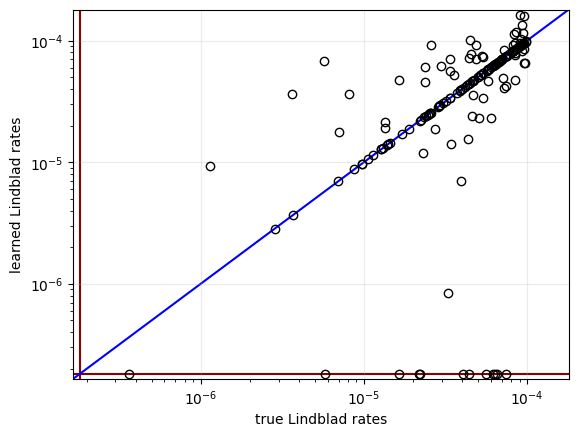

In [55]:
from matplotlib import pyplot as plt

learned_vs_true = np.array(
    [rand_rates, fit_rates]
)

epsilon = min(learned_vs_true[learned_vs_true > 0]) / 2.0
learned_vs_true[learned_vs_true == 0] = epsilon
lims = (np.min(learned_vs_true) * 0.9, np.max(learned_vs_true) * 1.1)
plt.loglog(learned_vs_true[0], learned_vs_true[1], ls="", marker="o", color="black", mfc="none")
plt.axvline(epsilon, color="darkred", zorder=-1)
plt.axhline(epsilon, color="darkred", zorder=-1)
plt.plot(lims, lims, color="blue", zorder=-1)
plt.ylim(lims)
plt.xlim(lims)
plt.xlabel("true Lindblad rates")
plt.ylabel("learned Lindblad rates")
plt.grid(alpha=0.25)
plt.show()

In [56]:
unbound_paths = []
depths = []
observables = []
std = []

for path in experiment.paths:
    unbound_paths.append(path.without_depth())
    depths.append(path.depth if path.depth is not None else -1)
    observables.append(pauli_lindblad_model.fidelity_estimate(path, fit.model_data))
    std.append(0.)

fit_averaged_data = AveragedData.from_arrays(
    unbound_paths=unbound_paths,
    depths=depths,
    observables=observables,
    std=std,
    time_lbs=np.empty(len(observables), dtype="datetime64[us]"),
    time_ubs=np.empty(len(observables), dtype="datetime64[us]"),
)

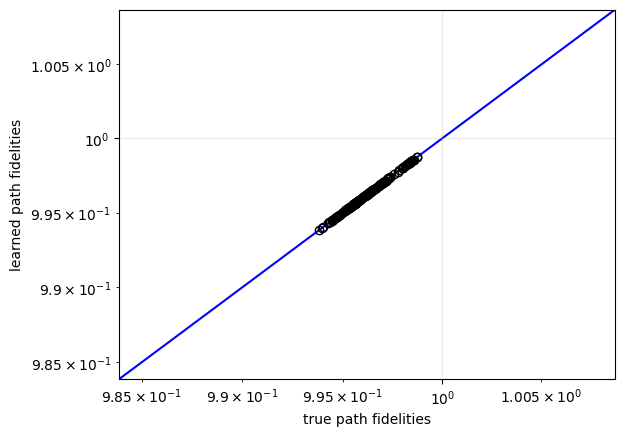

In [57]:
from matplotlib import pyplot as plt

learned_vs_true = np.array(
    [fit_averaged_data.dataset["observables"].data, 
     rand_averaged_data.dataset["observables"].data]
)

epsilon = min(learned_vs_true[learned_vs_true > 0]) / 2.0
learned_vs_true[learned_vs_true == 0] = epsilon
lims = (np.min(learned_vs_true) * 0.99, np.max(learned_vs_true) * 1.01)
plt.loglog(learned_vs_true[0], learned_vs_true[1], ls="", marker="o", color="black", mfc="none")
plt.axvline(epsilon, color="darkred", zorder=-1)
plt.axhline(epsilon, color="darkred", zorder=-1)
plt.plot(lims, lims, color="blue", zorder=-1)
plt.ylim(lims)
plt.xlim(lims)
plt.xlabel("true path fidelities")
plt.ylabel("learned path fidelities")
plt.grid(alpha=0.25)
plt.show()

In [58]:
from qiskit_noise_learning.math import IndexedVector

rate_diff = IndexedVector({k: v for k, v in zip(generator_indices, rand_rates-fit_rates)})


design_matrix = experiment.design_matrix

vec = np.zeros_like(fit_rates)
for generator_idx, matrix_idx in design_matrix.column_index_map.items():
    vec[matrix_idx] = rate_diff[generator_idx]

In [59]:
design_matrix.data @ vec

array([-4.37204526e-17, -3.25599465e-17,  1.52398168e-17, -1.44266652e-17,
        3.00256239e-17, -4.91753448e-17, -5.69138378e-17, -4.04610698e-17,
       -1.38777878e-17,  1.71710519e-17, -3.11843650e-17,  4.37069001e-17,
       -1.40539707e-17, -1.11401773e-17, -2.56549339e-17,  3.12385751e-17,
       -2.53296733e-17, -7.63346092e-18, -2.81994209e-17,  4.77387769e-18,
       -3.58667631e-17, -3.55550550e-17, -2.68848257e-17, -2.21820988e-17,
       -2.11554949e-17,  3.83163824e-17,  2.80537312e-18,  2.28969946e-17,
       -4.05491613e-17,  2.73151185e-17,  3.45386155e-17,  2.13045727e-17,
        1.34170019e-17,  5.14250643e-17, -2.61292724e-17,  3.19026489e-17,
        3.59006444e-17,  1.04489984e-17,  4.45471568e-17,  3.39490805e-17,
       -4.20670443e-17, -5.90551371e-18, -2.06269463e-17,  1.99357674e-17,
        5.24347276e-17,  1.53482370e-17,  1.94072189e-17, -5.30581438e-17,
        4.74338450e-19, -1.71981570e-17, -2.12774676e-18, -2.64003229e-17,
        7.86046575e-18,  